<a href="https://colab.research.google.com/github/aashitiwari555/Learning-ML/blob/main/Learning_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict categorical outcomes (like yes/no, spam/not spam).

Even though it has “regression” in the name, it is mainly used for classification.

---
**Why It Exists**

Linear regression predicts numbers, but classification needs:

*   Output between 0 and 1
*   Interpretable probability



So we apply a Sigmoid function:

𝜎(𝑧)=1/(1+e^(-1))

This squashes any value into (0,1).

---

Use it when:
*   Output is categorical (2 or multi-class)
*   Data is linearly separable
*   You want probability output
*   You want explainability

---

Step 1: Import Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

Step 2: Load

In [40]:
iris=load_iris()
x=iris.data
y=iris.target
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


Step 3: Train Test Split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42)

Step 4: Train Logistic Regression Model

In [42]:
model=LogisticRegression(max_iter=200)
model.fit(x_train,y_train)

LogisticRegression(max_iter=200)

Step 5: Make Predictions

In [43]:
y_pred = model.predict(x_test)

In [44]:
y_prob = model.predict_proba(x_test)
print(y_prob[:5])

[[3.80392750e-03 8.27739664e-01 1.68456409e-01]
 [9.46973015e-01 5.30267859e-02 1.98766047e-07]
 [8.86161500e-09 1.54855320e-03 9.98451438e-01]
 [6.48590621e-03 7.92228336e-01 2.01285757e-01]
 [1.45781656e-03 7.74128267e-01 2.24413916e-01]]


Step 6: Evaluate Model

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [46]:
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Visualizing Decision Boundary (2 Features Only)

In [48]:
X = iris.data[:, :2]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

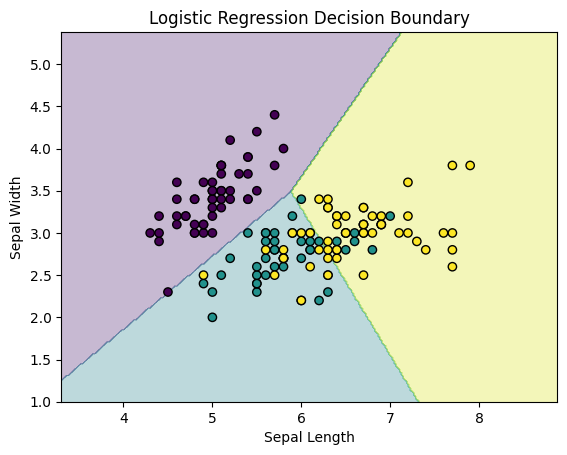

In [49]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Logistic Regression Decision Boundary")
plt.show()


#Perceptron

Perceptron is a binary linear classification algorithm that makes decisions using a weighted sum of inputs.

It is one of the first neural network models ever created (1958, Frank Rosenblatt).

---
**Real-World Analogy**

Imagine you're deciding:

"Should I study tonight or not?"

You consider: Deadline urgency, Mood, Energy level, Fear of failure

Each factor has a weight in your brain.

You mentally compute:

Decision score =w1×urgency + w2×mood + w3×energy + bias


If score > 0 → Study
Else → Sleep

That’s EXACTLY what perceptron does.

---
Mathematical Idea

Perceptron computes:

z = w1​x1 ​+ w2​x2 ​+ ... + b


Then applies step function:

If z ≥ 0 → Class 1
If z < 0 → Class 0

Unlike Logistic Regression:

Perceptron → hard 0/1 output

Logistic → probability output

---
**Limitation**
Perceptron ONLY works if data is:

✔️ Linearly separable
❌ Cannot handle complex patterns

This limitation led to neural networks later.

---
Where Is It Used?

Rarely used directly today but it is the foundation of neural networks

Single neuron in deep learning = generalized perceptron

Used in simple hardware-level classifiers

---


**Interesting Fact: The AI Winter**

In 1969, Marvin Minsky proved perceptron cannot solve XOR problem. Because of that, AI research funding dropped for 10 years.

That period is called **The AI Winter**

One limitation paused AI progress globally.

Step 1: Import and scaling

In [50]:
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)


Step 2: Convert to Binary Problem after loading (we have already loaded iris)

In [51]:
y = (y != 0).astype(int)

Step 3: Create Perceptron Model after splitting (we have already splitted training testing)

In [52]:
model = Perceptron(max_iter=1000, random_state=42)

Step 4: Train

In [53]:
model.fit(X_train, y_train)

Perceptron(random_state=42)

Step 5: Predict

In [54]:
y_pred = model.predict(X_test)

Step 6: Evaluate

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9333333333333333
[[10  0  0]
 [ 0  9  0]
 [ 0  2  9]]


Inspect Learned Weights

In [56]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [[-0.84210448  2.15018779 -1.64658307 -1.35709783]
 [ 0.2549677  -2.09801686  3.28170501 -1.75755292]
 [-0.89695809 -1.71791434  4.97795301  4.64972862]]
Bias: [-1. -1. -7.]


# Support Vector Machine (SVM)

Support Vector Machine is a supervised learning algorithm used for classification and regression that finds the optimal separating boundary with maximum margin.

---

**Real-World Analogy**

Imagine two groups of students:
* Engineers
* Designers

You want to draw a line separating them based on:
* Creativity score
* Math score
* Many lines can separate them.

But SVM asks:
Which line gives the largest safety gap between the two groups?

It chooses the line that is farthest from the nearest points of both classes.

* That distance is called Margin.
* The closest points are called Support Vectors.

They "support" the boundary.

---
**Why SVM Is Powerful**

Unlike perceptron:
* It does not just find ANY boundary.
* It finds the BEST boundary.

Unlike logistic regression:
* It focuses on boundary points only.
* It can handle non-linear data using kernels.

---

Hyperplane

* In 2D → line
* In 3D → plane
* In higher dimensions → hyperplane

---

**Kernel Trick (Most Important Part)**

If data is not linearly separable instead of drawing straight line, SVM can:
* Transform data into higher dimension. Then separate it linearly there.

Common kernels:
* Linear
* Polynomial
* RBF (Gaussian)

---

**Where SVM Is Used**
* Face detection
* Text classification
* Bioinformatics
* Handwriting recognition
* Image classification (before deep learning era)

---

**Interesting Fact**

Before deep learning SVM was THE most powerful classifier.
In 2000s competitions, SVM dominated.

Step 1: Imports

In [57]:
from sklearn.svm import SVC

Step 2: Train-Test Split (stratify) after loading (iris loaded already)

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Step 3: Scale Features (VERY IMPORTANT FOR SVM)

In [59]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

Step 4: Create Linear SVM

In [60]:
model = SVC(kernel='linear', C=1)
# C controls regularization.
# Large C → tries hard to classify all points correctly
# Small C → allows some mistakes but increases margin
# Think of C as Strictness parameter.

Step 5: Train

In [61]:
model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

Step 6: Predict and Evaluate

In [62]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
[[10  0]
 [ 0 20]]


Check Support Vectors

In [64]:
print("Number of support vectors:", model.n_support_)

Number of support vectors: [2 1]
